In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START,END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [21]:
def adder(state: AgentState) -> AgentState:
   """This node represents the first number for the addition operation"""
   state['finalNumber'] = state['number1'] + state['number2']
   return state

def subractor(state: AgentState) -> AgentState:
   """This node represents the first number for the subtraction operation"""
   state['finalNumber'] = state['number1'] - state['number2']
   return state

def decide_next_node(state:AgentState) -> str:
    """This node decides the next node to execute based on the operation"""
    
    if state['operation'] == '+' or state['operation'] == 'add':
        return 'add'
    
    elif state['operation'] == '-' or state['operation'] == 'subtract':
        return 'subtract'
        


In [22]:
graph = StateGraph(AgentState)

graph.add_node('add_node', adder)
graph.add_node('subtract_node', subractor)
graph.add_node('router_node', lambda state:state)
graph.add_edge(START, 'router_node')
graph.add_conditional_edges(
    'router_node',
    decide_next_node,
    {
        'add': 'add_node',
        'subtract': 'subtract_node'
    }
)

graph.add_edge('add_node', END)
graph.add_edge('subtract_node', END)
app = graph.compile()


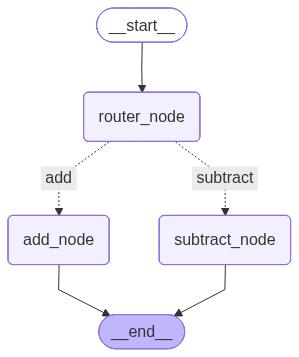

In [23]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [25]:
initial_state_1 = AgentState(number1=10, operation='+', number2=8)
result = app.invoke(initial_state_1)

In [26]:
print(result['finalNumber'])

18


In [41]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [42]:
class AgentState(TypedDict):
    number1:int
    operation1:str
    number2:int
    finalnumber1:int
    number3:int
    operation2:str
    number4:int
    finalnumber2:int

In [64]:
def adder(state:AgentState) -> AgentState:
   """This node represents the first number for the addition operation"""
   state['finalnumber1'] = state['number1'] + state['number2']
   return state

def subractor(state:AgentState) -> AgentState:
   """This node represents the first number for the subtraction operation"""
   state['finalnumber1'] = state['number1'] - state['number2']
   return state

def decide_next_node(state:AgentState) -> str:
    """This node decides the next node to execute based on the operation"""
    
    if state['operation1'] == '+' or state['operation1'] == 'add':
        return 'addition_operation'
    
    elif state['operation1'] == '-' or state['operation1'] == 'subtract':
        return 'subtraction_operation'

In [65]:
def adder2(state:AgentState) -> AgentState:
   """This node represents the first number for the addition operation"""
   state['finalnumber2'] = state['number3'] + state['number4']
   return state
def subractor2(state:AgentState) -> AgentState:
   """This node represents the first number for the subtraction operation"""
   state['finalnumber2'] = state['number3'] - state['number4']
   return state

def decide_next_node2(state:AgentState) -> str:
    """This node decides the next node to execute based on the operation"""
    
    if state['operation2'] == '+' or state['operation2'] == 'add':
        return 'addition_operation2'
    
    elif state['operation2'] == '-' or state['operation2'] == 'subtract':
        return 'subtraction_operation2'

In [66]:
graph = StateGraph(AgentState)
graph.add_node('add_node',adder)
graph.add_node('subtract_node',subractor)
graph.add_node('router_node', lambda state:state)

graph.add_node('add_node2',adder2)
graph.add_node('subtract_node2',subractor2)
graph.add_node('router_node2', lambda state:state)

graph.add_edge(START, 'router_node')

graph.add_conditional_edges(
    'router_node',
    decide_next_node,
    {
        'addition_operation': 'add_node',
        'subtraction_operation': 'subtract_node'
    }
)

graph.add_edge('add_node', 'router_node2')
graph.add_edge('subtract_node', 'router_node2')

graph.add_conditional_edges(
    'router_node2',
    decide_next_node2,
    {
        'addition_operation2': 'add_node2',
        'subtraction_operation2': 'subtract_node2'
    }
)
graph.add_edge('add_node2', END)
graph.add_edge('subtract_node2', END)
app = graph.compile()

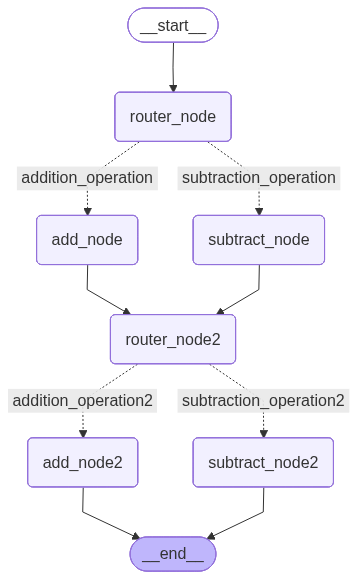

In [67]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [68]:
initial_state = AgentState(number1=10, operation1='+', number2=8 , number3=7,number4=5, operation2='-',finalnumber1=0, finalnumber2=0)

In [69]:
print(app.invoke(initial_state))

{'number1': 10, 'operation1': '+', 'number2': 8, 'finalnumber1': 18, 'number3': 7, 'operation2': '-', 'number4': 5, 'finalnumber2': 2}
